:meth:`SeqMutPlot.residue_mutation_impact` shows the ΔCPP of every substitution at a single residue.

CPP using the Python kernel fallback — the compiled Cython extension is not available in this install. Output is bit-exact with the Cython path but ~2x slower. Reinstall via `pip install --force-reinstall aaanalysis` to fetch a prebuilt wheel.


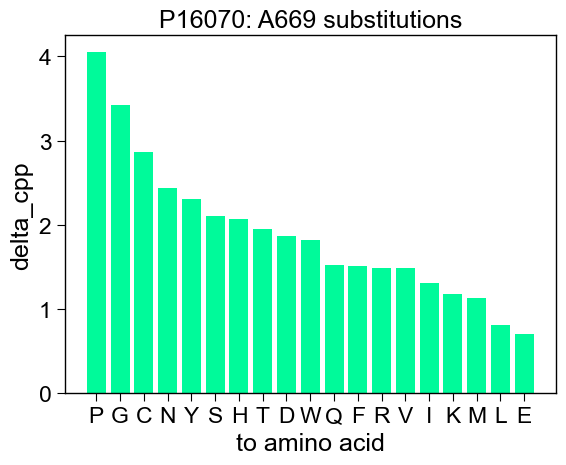

In [1]:
import matplotlib.pyplot as plt
import aaanalysis as aa
aa.options["verbose"] = False

df_seq = aa.load_dataset(name="DOM_GSEC", n=10)
labels = df_seq["label"].to_list()
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)
split_kws = sf.get_split_kws()
cpp = aa.CPP(df_parts=df_parts, split_kws=split_kws, verbose=False)
df_feat = cpp.run(labels=labels, n_filter=25)
aa.plot_settings()
df_scan = aa.SeqMut().scan(df_seq=df_seq, df_feat=df_feat, region="tmd")
row = df_scan.iloc[0]
aa.SeqMutPlot().residue_mutation_impact(df_scan=df_scan, entry=row["entry"], pos=int(row["pos"]))
plt.tight_layout()
plt.show()